# 第11周：内部验证、敏感性分析与结果稳定性

**任务书第11周要求**
1. leave-one-mouse-out（LOSO）重新估计衰老方向，与完整数据结果比较
2. 敏感性分析：HVG=2000/3000/5000、PC=10/20/30、最小细胞数 30/50、均值/10%截尾均值
3. mouse-level bootstrap B=500
4. 输出：`results/sensitivity/sensitivity_summary.tsv`、`figures/supplement/stability_plots.pdf`、`docs/result_stability_notes.md`

**重要说明**
- 第10周的"PCA衰老方向与相似性"基线输出（`results/aging_axis/`）此前未生成，本 notebook 先补齐基线（Cell 2–4），再做敏感性分析
- 方向定义 d(t,c) = μ(old) − μ(young)，中心只用 young/old 小鼠计算；被留出的小鼠不参与中心估计（无信息泄漏）
- 统计单位为独立小鼠；young 或 old 小鼠数不足 2 的节点不进入方向分析，并记入失败日志
- HVG 敏感性的 cell 最耗时（需在全基因对象上重跑 PCA），请放在 Colab 上运行

In [1]:
# ===================== 0. 环境配置与全局参数 =====================
# 输出物（任务书第11周）:
#   results/sensitivity/sensitivity_summary.tsv
#   figures/supplement/stability_plots.pdf
#   docs/result_stability_notes.md
# 同时补齐第10周基线输出:
#   results/aging_axis/pca_scores.csv / aging_directions.csv / cosine_similarity.csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

SEED = 2026
np.random.seed(SEED)

BASE = Path('..')
RESULTS = BASE / 'results'
SENS_DIR = RESULTS / 'sensitivity'
AXIS_DIR = RESULTS / 'aging_axis'
FIG_DIR = BASE / 'figures' / 'supplement'
DOCS = BASE / 'docs'
for d in (SENS_DIR, AXIS_DIR, FIG_DIR, DOCS):
    d.mkdir(parents=True, exist_ok=True)

# 冻结的年龄分组（config/analysis_parameters_v1.yaml）
AGE_MAP = {1: 'young', 3: 'young', 18: 'middle', 21: 'middle', 24: 'old', 30: 'old'}
YOUNG, OLD = 'young', 'old'
PC_BASE = 30                # 衰老方向使用的 PC 数
MIN_YOUNG, MIN_OLD = 2, 2   # 节点进入方向分析所需的最少 young/old 小鼠数

sens_rows = []   # 敏感性结果汇总
failures = []    # 失败/排除日志
print('✅ 环境就绪, 随机种子 SEED =', SEED)

import matplotlib.pyplot as plt
import matplotlib

# ========== 解决中文显示为方框的问题 ==========
# 方法3: Windows 系统 (取消注释下面一行)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# =============================================

✅ 环境就绪, 随机种子 SEED = 2026


In [2]:
# ===================== 1. 加载基线 mouse-level PCA 矩阵并审计节点覆盖 =====================
pca_df = pd.read_csv(RESULTS / 'pca' / 'mouse_level_pca.csv', index_col=0).reset_index()
pc_cols_all = sorted([c for c in pca_df.columns if c.startswith('PC')],
                     key=lambda x: int(x[2:]))
pca_df = pca_df.dropna(subset=pc_cols_all).copy()          # 只保留有有效PCA坐标的样本
pca_df['mouse.id'] = pca_df['mouse.id'].astype(str)
pca_df['age_group'] = pca_df['age_months'].map(AGE_MAP)
pca_df['node'] = pca_df['tissue'].astype(str) + '__' + pca_df['major_cell_type'].astype(str)

# 节点覆盖审计（每个年龄组的独立小鼠数）
cov = pca_df.groupby(['node', 'age_group'])['mouse.id'].nunique().unstack(fill_value=0)
for col in ('young', 'middle', 'old'):
    if col not in cov.columns:
        cov[col] = 0
cov = cov[['young', 'middle', 'old']]
cov['n_mice'] = pca_df.groupby('node')['mouse.id'].nunique()
print('节点覆盖（独立小鼠数）:')
print(cov)

valid_nodes = cov[(cov['young'] >= MIN_YOUNG) & (cov['old'] >= MIN_OLD)].index.tolist()
for nd in cov.index:
    if nd not in valid_nodes:
        row = cov.loc[nd]
        failures.append({'step': 'node_selection', 'item': nd,
                         'reason': 'young=%d, old=%d 不足，排除出衰老方向分析' % (row['young'], row['old'])})
print('\n进入分析的节点 (%d): %s' % (len(valid_nodes), valid_nodes))
pca_df = pca_df[pca_df['node'].isin(valid_nodes)].copy()

节点覆盖（独立小鼠数）:
age_group                            young  middle  old  n_mice
node                                                           
Fat__endothelial                         0       5    1       6
Fat__fibroblast/stromal                  0       5    1       6
Heart_and_Aorta__endothelial             2       5    4      11
Heart_and_Aorta__fibroblast/stromal      2       5    4      11
Kidney__endothelial                      5       5    4      14
Kidney__fibroblast/stromal               5       5    4      14
Liver__endothelial                       5       2    5      12
Liver__fibroblast/stromal                3       2    1       6
Lung__endothelial                        4       6    4      14
Lung__fibroblast/stromal                 6       6    4      16

进入分析的节点 (7): ['Heart_and_Aorta__endothelial', 'Heart_and_Aorta__fibroblast/stromal', 'Kidney__endothelial', 'Kidney__fibroblast/stromal', 'Liver__endothelial', 'Lung__endothelial', 'Lung__fibroblast/stromal']


In [3]:
# ===================== 2. 基线衰老方向与小鼠投影得分 =====================
# d(t,c) = mu(old) - mu(young);  A(m) = (z_m - mu_young) · d / ||d||
def node_direction(sub, n_pc=PC_BASE):
    cols = pc_cols_all[:n_pc]
    mu_y = sub.loc[sub['age_group'] == YOUNG, cols].values.mean(axis=0)
    mu_o = sub.loc[sub['age_group'] == OLD, cols].values.mean(axis=0)
    return mu_o - mu_y, mu_y, mu_o

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def project_scores(sub, d, mu_young, n_pc=PC_BASE):
    X = sub[pc_cols_all[:n_pc]].values
    return (X - mu_young) @ d / np.linalg.norm(d)

directions, scores_list = {}, []
for nd in valid_nodes:
    sub = pca_df[pca_df['node'] == nd]
    d, mu_y, mu_o = node_direction(sub)
    directions[nd] = d
    tmp = sub[['mouse.id', 'tissue', 'major_cell_type', 'age_months', 'age_group']].copy()
    tmp['aging_score'] = project_scores(sub, d, mu_y)
    tmp['node'] = nd
    rho, pval = stats.spearmanr(tmp['aging_score'], tmp['age_months'])
    tmp['spearman_rho'] = rho
    tmp['spearman_p'] = pval
    scores_list.append(tmp)
    print('%s: ||d||=%.2f, Spearman rho=%.3f (p=%.3g), n=%d 只小鼠'
          % (nd, np.linalg.norm(d), rho, pval, len(tmp)))

pca_scores = pd.concat(scores_list, ignore_index=True)
pca_scores.to_csv(AXIS_DIR / 'pca_scores.csv', index=False)
pd.DataFrame(directions).to_csv(AXIS_DIR / 'aging_directions.csv')
print('\n✅ 基线已保存 -> results/aging_axis/pca_scores.csv, aging_directions.csv')

Heart_and_Aorta__endothelial: ||d||=3.68, Spearman rho=0.855 (p=0.000805), n=11 只小鼠
Heart_and_Aorta__fibroblast/stromal: ||d||=4.97, Spearman rho=0.832 (p=0.00151), n=11 只小鼠
Kidney__endothelial: ||d||=3.55, Spearman rho=0.874 (p=4.31e-05), n=14 只小鼠
Kidney__fibroblast/stromal: ||d||=12.77, Spearman rho=0.908 (p=7.12e-06), n=14 只小鼠
Liver__endothelial: ||d||=6.28, Spearman rho=0.804 (p=0.00161), n=12 只小鼠
Lung__endothelial: ||d||=3.41, Spearman rho=0.907 (p=7.75e-06), n=14 只小鼠
Lung__fibroblast/stromal: ||d||=4.39, Spearman rho=0.660 (p=0.00542), n=16 只小鼠

✅ 基线已保存 -> results/aging_axis/pca_scores.csv, aging_directions.csv


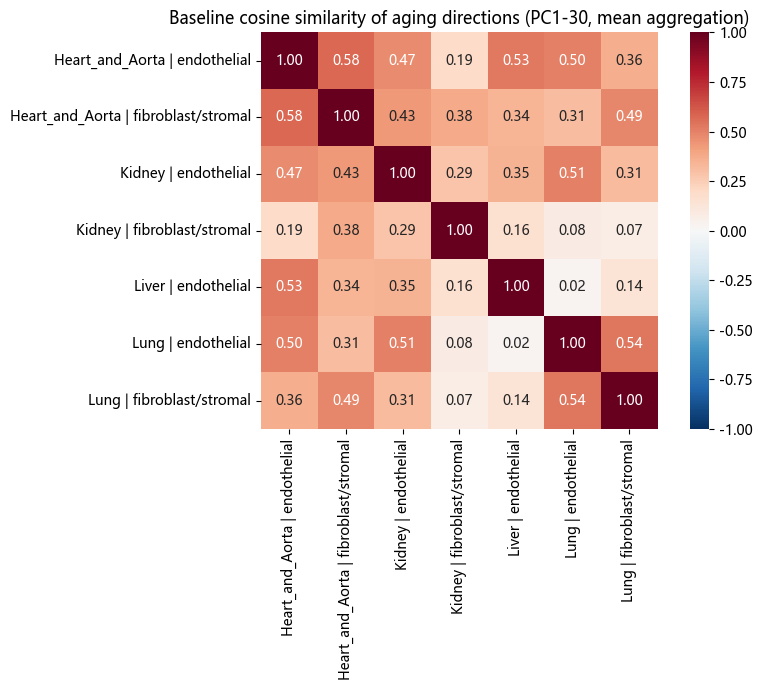

✅ 已保存 -> results/aging_axis/cosine_similarity.csv


In [4]:
# ===================== 3. 基线节点间余弦相似度 =====================
def cosine_matrix(dirs):
    keys = list(dirs.keys())
    m = pd.DataFrame(np.nan, index=keys, columns=keys)
    for i in keys:
        for j in keys:
            m.loc[i, j] = cosine(dirs[i], dirs[j])
    return m

cos_base = cosine_matrix(directions)
cos_base.to_csv(AXIS_DIR / 'cosine_similarity.csv')

plt.figure(figsize=(9, 7))
sns.heatmap(cos_base.rename(index=lambda s: s.replace('__', ' | '),
                            columns=lambda s: s.replace('__', ' | ')),
            cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f', square=True)
plt.title('Baseline cosine similarity of aging directions (PC1-%d, mean aggregation)' % PC_BASE)
plt.tight_layout()
plt.show()
print('✅ 已保存 -> results/aging_axis/cosine_similarity.csv')

In [5]:
# ===================== 4. 留一小鼠（LOSO）重估衰老方向 =====================
# 每只小鼠被逐一留出；重估方向时该小鼠不参与中心计算（无泄漏）
loso_rows = []
for nd in valid_nodes:
    sub = pca_df[pca_df['node'] == nd]
    d_full, mu_y_full, _ = node_direction(sub)
    for m in sub['mouse.id'].unique():
        train = sub[sub['mouse.id'] != m]
        if (train['age_group'] == YOUNG).sum() < 1 or (train['age_group'] == OLD).sum() < 1:
            failures.append({'step': 'loso', 'item': '%s|%s' % (nd, m),
                             'reason': '留出后 young 或 old 组为空，跳过'})
            continue
        d_loso, mu_y_loso, _ = node_direction(train)
        held = sub[sub['mouse.id'] == m]
        lo = held.iloc[0]
        sc_full = float(project_scores(held, d_full, mu_y_full)[0])
        sc_loso = float(project_scores(held, d_loso, mu_y_loso)[0])
        loso_rows.append({'node': nd, 'left_out_mouse': m,
                          'age_months': lo['age_months'], 'age_group': lo['age_group'],
                          'cos_vs_full': cosine(d_loso, d_full),
                          'score_full': sc_full, 'score_loso': sc_loso})

loso_df = pd.DataFrame(loso_rows)
loso_df.to_csv(SENS_DIR / 'loso_aging_direction.csv', index=False)
stab = loso_df.groupby('node')['cos_vs_full'].agg(['mean', 'min', 'std'])
print('LOSO 方向稳定性（与完整数据方向的余弦）:')
print(stab)
for nd in valid_nodes:
    s = stab.loc[nd]
    sens_rows.append({'analysis': 'leave_one_mouse_out', 'parameter': nd,
                      'metric': 'cosine_vs_full_direction_mean', 'value': s['mean']})
    sens_rows.append({'analysis': 'leave_one_mouse_out', 'parameter': nd,
                      'metric': 'cosine_vs_full_direction_min', 'value': s['min']})

LOSO 方向稳定性（与完整数据方向的余弦）:
                                         mean       min       std
node                                                             
Heart_and_Aorta__endothelial         0.947916  0.759420  0.091395
Heart_and_Aorta__fibroblast/stromal  0.976997  0.873195  0.040844
Kidney__endothelial                  0.988275  0.966517  0.011682
Kidney__fibroblast/stromal           0.997798  0.988253  0.003423
Liver__endothelial                   0.991095  0.966745  0.010156
Lung__endothelial                    0.969533  0.884317  0.035556
Lung__fibroblast/stromal             0.964031  0.576896  0.104142


In [6]:
# ===================== 5. 敏感性：PC 数量（10/20/30），基线 HVG=3000 =====================
for n_pc in (10, 20, 30):
    dirs = {}
    for nd in valid_nodes:
        sub = pca_df[pca_df['node'] == nd]
        d, mu_y, _ = node_direction(sub, n_pc=n_pc)
        dirs[nd] = d
        scv = project_scores(sub, d, mu_y, n_pc=n_pc)
        rho = stats.spearmanr(scv, sub['age_months'].values)[0]
        # 基线方向截取前 n_pc 个分量：PC 基底有序且同子空间，截断后为同口径比较（结果应≈1，属完整性检查）
        sens_rows.append({'analysis': 'n_pcs', 'parameter': '%s|PC%d' % (nd, n_pc),
                          'metric': 'cosine_direction_vs_baseline',
                          'value': cosine(d, directions[nd][:n_pc])})
        sens_rows.append({'analysis': 'n_pcs', 'parameter': '%s|PC%d' % (nd, n_pc),
                          'metric': 'spearman_score_vs_age', 'value': rho})
    cm = cosine_matrix(dirs)
    keys = list(dirs.keys())
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            sens_rows.append({'analysis': 'n_pcs',
                              'parameter': '%s vs %s|PC%d' % (keys[i], keys[j], n_pc),
                              'metric': 'pairwise_cosine', 'value': cm.iloc[i, j],
                              'baseline': cos_base.loc[keys[i], keys[j]]})
    print('PC=%d 完成' % n_pc)

PC=10 完成
PC=20 完成
PC=30 完成


In [7]:
# ===================== 6. 敏感性：汇总方式（均值 vs 10%截尾均值）=====================
# 从冻结对象的细胞级 PCA 重新计算 mouse-level 坐标，再重估方向
import anndata as ad
from scipy.stats import trim_mean

adat = ad.read_h5ad(BASE / 'data_processed' / 'main_qc_pca.h5ad')
Xp_full = np.asarray(adat.obsm['X_pca'])
obs_cell = adat.obs[['mouse.id', 'tissue', 'major_cell_type', 'age_months']].copy()
obs_cell['mouse.id'] = obs_cell['mouse.id'].astype(str)
obs_cell['node'] = obs_cell['tissue'].astype(str) + '__' + obs_cell['major_cell_type'].astype(str)
obs_cell['_pos'] = np.arange(len(obs_cell))

def mouse_level_from_cells(X, meta, how='mean', n_pc=PC_BASE, min_cells=1):
    rows = []
    for (m, nd), g in meta.groupby(['mouse.id', 'node']):
        subX = X[g['_pos'].values][:, :n_pc]
        if len(subX) < min_cells:
            continue
        z = subX.mean(axis=0) if how == 'mean' else trim_mean(subX, 0.1, axis=0)
        row = {'mouse.id': m, 'node': nd, 'age_months': g['age_months'].iloc[0],
               'n_cells': len(subX)}
        row.update({'PC%d' % (i + 1): z[i] for i in range(n_pc)})
        rows.append(row)
    out = pd.DataFrame(rows)
    out['age_group'] = out['age_months'].map(AGE_MAP)
    out[['tissue', 'major_cell_type']] = out['node'].str.split('__', n=1, expand=True)
    return out

valid_samples = set(zip(pca_df['mouse.id'], pca_df['node']))
agg_results = {}
for how in ('mean', 'trim_mean'):
    ml = mouse_level_from_cells(Xp_full, obs_cell, how=how)
    ml = ml[ml.apply(lambda r: (r['mouse.id'], r['node']) in valid_samples, axis=1)]
    dirs = {}
    for nd in valid_nodes:
        sub = ml[ml['node'] == nd]
        d, mu_y, _ = node_direction(sub)
        dirs[nd] = d
        scv = project_scores(sub, d, mu_y)
        rho = stats.spearmanr(scv, sub['age_months'].values)[0]
        sens_rows.append({'analysis': 'aggregation', 'parameter': '%s|%s' % (nd, how),
                          'metric': 'cosine_direction_vs_baseline',
                          'value': cosine(d, directions[nd])})
        sens_rows.append({'analysis': 'aggregation', 'parameter': '%s|%s' % (nd, how),
                          'metric': 'spearman_score_vs_age', 'value': rho})
    agg_results[how] = dirs
    print('%s: %d 个样本' % (how, len(ml)))

chk = np.mean([cosine(agg_results['mean'][nd], directions[nd]) for nd in valid_nodes])
print('完整性检查: 均值汇总 vs 基线方向的平均余弦 = %.4f（应接近 1）' % chk)

mean: 92 个样本
trim_mean: 92 个样本
完整性检查: 均值汇总 vs 基线方向的平均余弦 = 1.0000（应接近 1）


In [8]:
# ===================== 7. 敏感性：最小细胞数（30/50）=====================
lib = pd.read_csv(RESULTS / 'pseudobulk' / 'library_qc.csv')
lib['mouse.id'] = lib['mouse.id'].astype(str)
lib['node'] = lib['tissue'].astype(str) + '__' + lib['major_cell_type'].astype(str)
ncell = dict(zip(zip(lib['mouse.id'], lib['node']), lib['n_cells']))
pca_df['n_cells'] = [ncell.get((m, n), np.nan) for m, n in zip(pca_df['mouse.id'], pca_df['node'])]

for min_c in (30, 50):
    sub_all = pca_df[pca_df['n_cells'] >= min_c]
    print('min_cells=%d: 保留 %d/%d 样本' % (min_c, len(sub_all), len(pca_df)))
    for nd in valid_nodes:
        sub = sub_all[sub_all['node'] == nd]
        ny, no = int((sub['age_group'] == YOUNG).sum()), int((sub['age_group'] == OLD).sum())
        if ny < 1 or no < 1:
            failures.append({'step': 'min_cells_%d' % min_c, 'item': nd,
                             'reason': '过滤后 young=%d, old=%d，无法估计方向' % (ny, no)})
            sens_rows.append({'analysis': 'min_cells_%d' % min_c, 'parameter': nd,
                              'metric': 'feasible', 'value': 0.0})
            continue
        d, mu_y, _ = node_direction(sub)
        scv = project_scores(sub, d, mu_y)
        rho = stats.spearmanr(scv, sub['age_months'].values)[0]
        sens_rows.append({'analysis': 'min_cells_%d' % min_c, 'parameter': nd,
                          'metric': 'feasible', 'value': 1.0})
        sens_rows.append({'analysis': 'min_cells_%d' % min_c, 'parameter': nd,
                          'metric': 'cosine_direction_vs_baseline',
                          'value': cosine(d, directions[nd])})
        sens_rows.append({'analysis': 'min_cells_%d' % min_c, 'parameter': nd,
                          'metric': 'spearman_score_vs_age', 'value': rho})
        sens_rows.append({'analysis': 'min_cells_%d' % min_c, 'parameter': nd,
                          'metric': 'n_samples_kept', 'value': float(len(sub))})

min_cells=30: 保留 58/92 样本
min_cells=50: 保留 48/92 样本


In [9]:
# ===================== 8. 敏感性：HVG=2000/5000（基线 3000）=====================
# 在全基因对象（限定到冻结队列细胞）上重选 HVG 并重跑 PCA，再重估方向
import scanpy as sc

try:
    # 全基因对象：优先 data_interim/normalized.h5ad（106368x20138，log归一化，
    # 实测 100% 覆盖冻结队列 14257 细胞）；results/qc/adata_log_normalized.h5ad 仅覆盖 81.6%，作回退
    hvg_src = BASE / 'data_interim' / 'normalized.h5ad'
    if not hvg_src.exists():
        hvg_src = BASE / 'results' / 'qc' / 'adata_log_normalized.h5ad'
        print('⚠️ normalized.h5ad 不存在，回退使用 adata_log_normalized.h5ad（细胞覆盖率较低）')
    print('HVG敏感性输入:', hvg_src)
    full = ad.read_h5ad(hvg_src)

    # ---- 细胞标识匹配 ----
    # anndata 读取 h5ad 时会把 obs/index 吸收进行名 obs_names，此时 obs 中不再有 'index' 列。
    # 因此自动选择匹配标识：优先用两侧都存在的 'index' / 'cell' 列，否则回退用 obs_names。
    def _ids(ad, key):
        if key is None:
            return pd.Series(ad.obs_names.astype(str)).reset_index(drop=True)
        return pd.Series(np.asarray(ad.obs[key]).astype(str)).reset_index(drop=True)

    match_key = next((c for c in ('index', 'cell')
                      if c in full.obs.columns and c in adat.obs.columns), None)
    print('细胞标识匹配列:', match_key if match_key else 'obs_names（index 列已被吸收进行名）')

    anno = adat.obs[['mouse.id', 'tissue', 'major_cell_type', 'age_months']].reset_index(drop=True).copy()
    anno['_aid'] = _ids(adat, match_key).values
    anno['mouse.id'] = anno['mouse.id'].astype(str)
    tmp = pd.DataFrame({'_aid': _ids(full, match_key).values,
                        '_obsname': full.obs_names.astype(str)})
    merged = tmp.merge(anno, on='_aid', how='inner').drop_duplicates('_obsname')
    assert len(merged) > 10000, '匹配细胞过少(%d)，请检查细胞标识一致性' % len(merged)

    full_sub = full[merged['_obsname'].values].copy()
    full_sub.obs['node'] = (merged['tissue'].astype(str) + '__' + merged['major_cell_type'].astype(str)).values
    full_sub.obs['mouse.id'] = merged['mouse.id'].values
    full_sub.obs['age_months'] = merged['age_months'].values
    print('匹配到冻结队列细胞 %d 个' % len(full_sub))

    chk_x = full_sub.X[:200]
    chk_x = chk_x.toarray() if hasattr(chk_x, 'toarray') else np.asarray(chk_x)
    looks_counts = np.allclose(chk_x, np.round(chk_x)) and chk_x.max() > 50
    print('X 类型判断:', '原始counts → 先标准化' if looks_counts else 'log-normalized → 直接做HVG')

    meta_hvg = full_sub.obs[['mouse.id', 'node', 'age_months']].copy()
    meta_hvg['_pos'] = np.arange(len(meta_hvg))

    for n_hvg in (2000, 5000):
        a = full_sub.copy()
        if looks_counts:
            sc.pp.normalize_total(a, target_sum=1e4)
            sc.pp.log1p(a)
        sc.pp.highly_variable_genes(a, n_top_genes=n_hvg, flavor='seurat')
        a = a[:, a.var['highly_variable'].values].copy()
        sc.pp.scale(a, max_value=10)
        sc.tl.pca(a, n_comps=PC_BASE, svd_solver='arpack', random_state=SEED)
        ml = mouse_level_from_cells(np.asarray(a.obsm['X_pca']), meta_hvg, how='mean')
        ml = ml[ml.apply(lambda r: (r['mouse.id'], r['node']) in valid_samples, axis=1)]
        for nd in valid_nodes:
            sub = ml[ml['node'] == nd]
            if len(sub) < 3:
                continue
            d, mu_y, _ = node_direction(sub)
            scv = project_scores(sub, d, mu_y)
            rho = stats.spearmanr(scv, sub['age_months'].values)[0]
            sens_rows.append({'analysis': 'n_hvg', 'parameter': '%s|HVG%d' % (nd, n_hvg),
                              'metric': 'cosine_direction_vs_baseline',
                              'value': cosine(d, directions[nd])})
            sens_rows.append({'analysis': 'n_hvg', 'parameter': '%s|HVG%d' % (nd, n_hvg),
                              'metric': 'spearman_score_vs_age', 'value': rho})
        print('HVG=%d 完成' % n_hvg)
except Exception as e:
    failures.append({'step': 'n_hvg', 'item': 'HVG敏感性分析',
                     'reason': '%s: %s' % (type(e).__name__, e)})
    print('⚠️ HVG敏感性运行失败，已记入日志:', e)

HVG敏感性输入: ..\data_interim\normalized.h5ad
细胞标识匹配列: cell
匹配到冻结队列细胞 14257 个
X 类型判断: 原始counts → 先标准化
HVG=2000 完成
HVG=5000 完成


In [10]:
# ===================== 9. mouse-level bootstrap（B=500）=====================
# 对 young/old 小鼠分别做有放回重抽样，重估方向，得到稳定性指标的 95% CI
B = 500
rng = np.random.default_rng(SEED)
boot_cos = {nd: [] for nd in valid_nodes}
boot_rho = {nd: [] for nd in valid_nodes}
pair_boot = {(a, b): [] for i, a in enumerate(valid_nodes) for b in valid_nodes[i + 1:]}
node_tables = {nd: pca_df[pca_df['node'] == nd] for nd in valid_nodes}

for b in range(B):
    dirs = {}
    for nd in valid_nodes:
        sub = node_tables[nd]
        ym = sub.loc[sub['age_group'] == YOUNG, 'mouse.id'].unique()
        om = sub.loc[sub['age_group'] == OLD, 'mouse.id'].unique()
        y_parts = [sub[sub['mouse.id'] == m] for m in rng.choice(ym, size=len(ym), replace=True)]
        o_parts = [sub[sub['mouse.id'] == m] for m in rng.choice(om, size=len(om), replace=True)]
        yb, ob = pd.concat(y_parts), pd.concat(o_parts)
        boot = pd.concat([yb.assign(age_group=YOUNG), ob.assign(age_group=OLD)])
        d, mu_y, _ = node_direction(boot)
        dirs[nd] = d
        boot_cos[nd].append(cosine(d, directions[nd]))
        scv = project_scores(sub, d, mu_y)
        boot_rho[nd].append(stats.spearmanr(scv, sub['age_months'].values)[0])
    keys = list(dirs.keys())
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            pair_boot[(keys[i], keys[j])].append(cosine(dirs[keys[i]], dirs[keys[j]]))
    if (b + 1) % 100 == 0:
        print('bootstrap %d/%d' % (b + 1, B))

ci_rows = []
for nd in valid_nodes:
    lo, hi = np.percentile(boot_cos[nd], [2.5, 97.5])
    ci_rows.append({'node': nd, 'metric': 'cosine_boot_vs_full',
                    'mean': float(np.mean(boot_cos[nd])), 'ci_low': lo, 'ci_high': hi})
    lo, hi = np.percentile(boot_rho[nd], [2.5, 97.5])
    ci_rows.append({'node': nd, 'metric': 'spearman_score_age',
                    'mean': float(np.mean(boot_rho[nd])), 'ci_low': lo, 'ci_high': hi})
for (a, bnd), vals in pair_boot.items():
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ci_rows.append({'node': '%s vs %s' % (a, bnd), 'metric': 'pairwise_cosine',
                    'mean': float(np.mean(vals)), 'ci_low': lo, 'ci_high': hi})
boot_ci = pd.DataFrame(ci_rows)
boot_ci.to_csv(SENS_DIR / 'bootstrap_ci.csv', index=False)
print('✅ bootstrap 完成 -> results/sensitivity/bootstrap_ci.csv')

bootstrap 100/500
bootstrap 200/500
bootstrap 300/500
bootstrap 400/500
bootstrap 500/500
✅ bootstrap 完成 -> results/sensitivity/bootstrap_ci.csv


In [11]:
# ===================== 10. 汇总 sensitivity_summary.tsv 与失败日志 =====================
for r in ci_rows:
    if r['metric'] == 'pairwise_cosine':
        continue
    sens_rows.append({'analysis': 'bootstrap_B500', 'parameter': r['node'],
                      'metric': r['metric'] + '_mean', 'value': r['mean']})
    sens_rows.append({'analysis': 'bootstrap_B500', 'parameter': r['node'],
                      'metric': r['metric'] + '_ci95_low', 'value': r['ci_low']})
    sens_rows.append({'analysis': 'bootstrap_B500', 'parameter': r['node'],
                      'metric': r['metric'] + '_ci95_high', 'value': r['ci_high']})

sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv(SENS_DIR / 'sensitivity_summary.tsv', sep='\t', index=False)
print('各分析维度行数:')
print(sens_df.groupby('analysis').size())
if failures:
    pd.DataFrame(failures).to_csv(SENS_DIR / 'failure_log.tsv', sep='\t', index=False)
    print('⚠️ 排除/失败日志已保存 -> results/sensitivity/failure_log.tsv (%d 条)' % len(failures))
print('✅ 已保存 -> results/sensitivity/sensitivity_summary.tsv')

各分析维度行数:
analysis
aggregation             28
bootstrap_B500          42
leave_one_mouse_out     14
min_cells_30            22
min_cells_50            19
n_hvg                   28
n_pcs                  105
dtype: int64
⚠️ 排除/失败日志已保存 -> results/sensitivity/failure_log.tsv (8 条)
✅ 已保存 -> results/sensitivity/sensitivity_summary.tsv


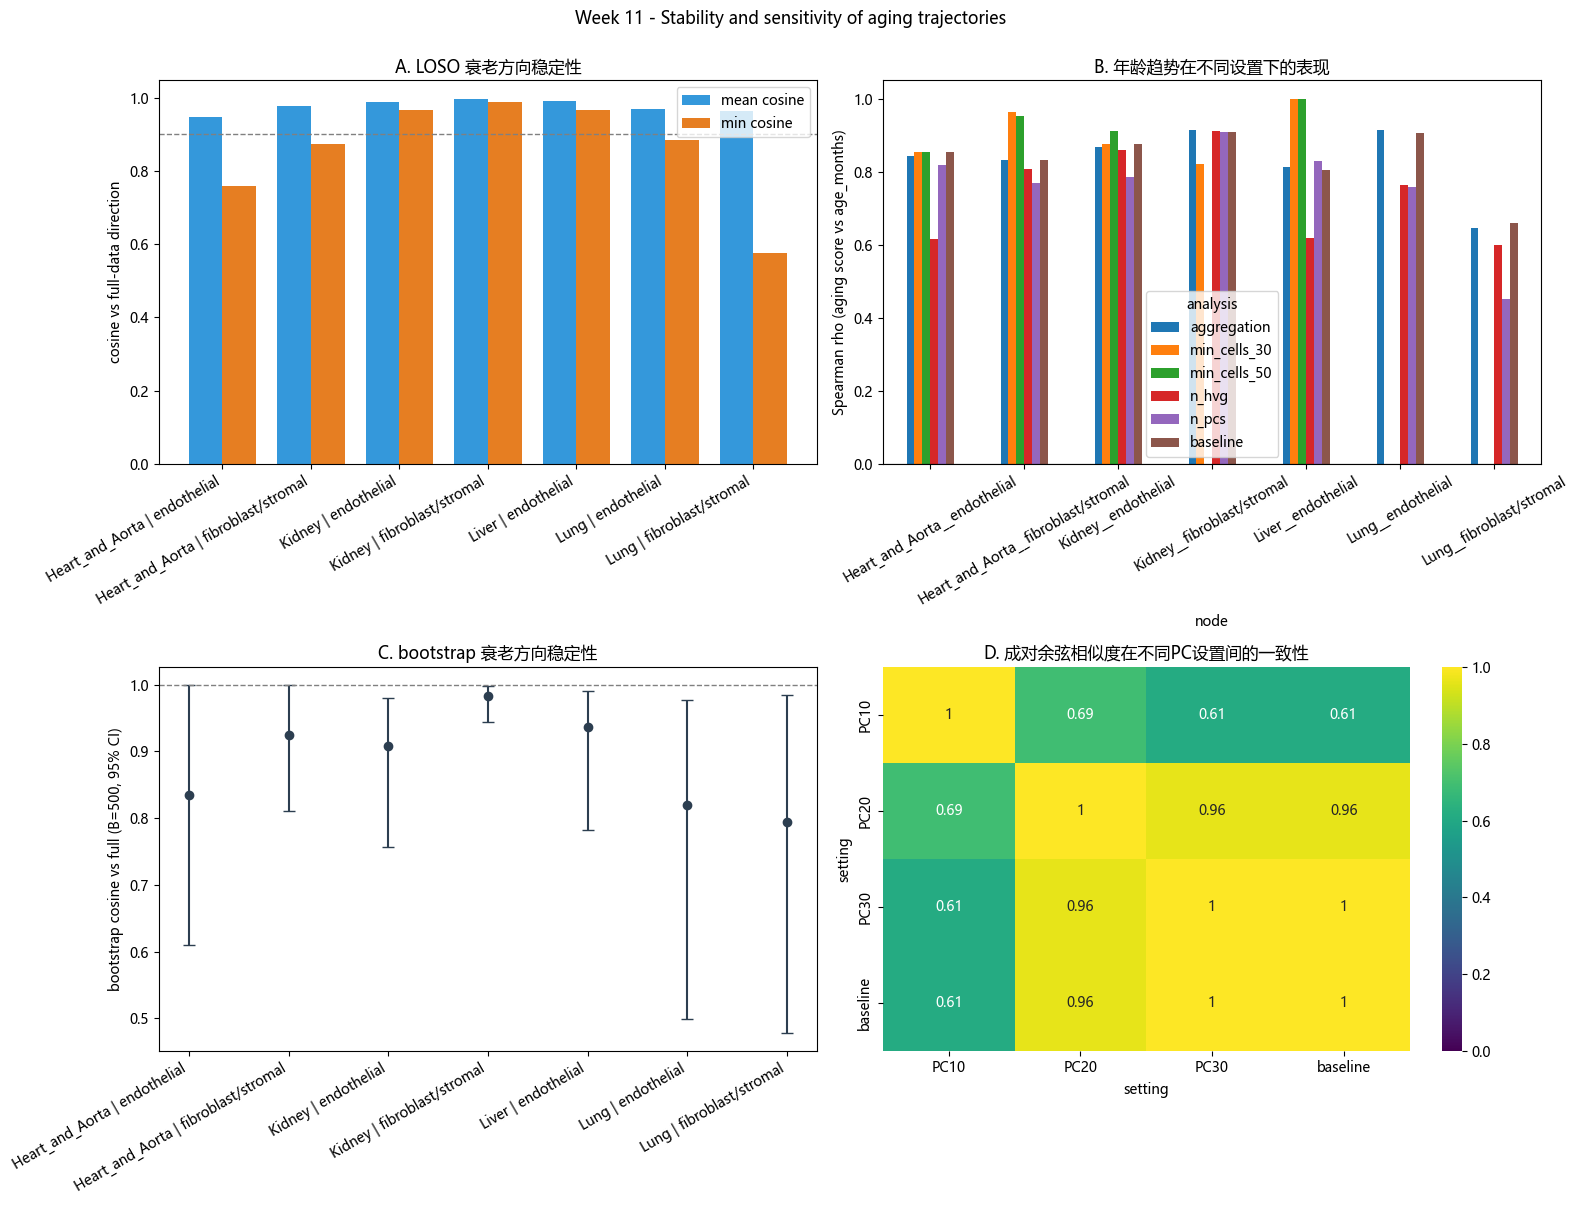

✅ 已保存 -> figures/supplement/stability_plots.pdf


In [12]:
# ===================== 11. 稳定性汇总图（figures/supplement/stability_plots.pdf）=====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. LOSO 方向稳定性
ax = axes[0, 0]
stab_plot = loso_df.groupby('node')['cos_vs_full'].agg(['mean', 'min'])
x = np.arange(len(stab_plot))
w = 0.38
ax.bar(x - w / 2, stab_plot['mean'], w, label='mean cosine', color='#3498db')
ax.bar(x + w / 2, stab_plot['min'], w, label='min cosine', color='#e67e22')
ax.axhline(0.9, ls='--', c='gray', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([n.replace('__', ' | ') for n in stab_plot.index], rotation=30, ha='right')
ax.set_ylabel('cosine vs full-data direction')
ax.set_title('A. LOSO 衰老方向稳定性')
ax.legend()

# B. 各设置下得分-年龄趋势
ax = axes[0, 1]
plot_df = sens_df[sens_df['metric'] == 'spearman_score_vs_age'].copy()
plot_df['node'] = plot_df['parameter'].str.split('|').str[0]
pv = plot_df.pivot_table(index='node', columns='analysis', values='value', aggfunc='mean')
pv['baseline'] = pca_scores.groupby('node')['spearman_rho'].first()
pv = pv.reindex(valid_nodes)
pv.plot(kind='bar', ax=ax, rot=30)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('Spearman rho (aging score vs age_months)')
ax.set_title('B. 年龄趋势在不同设置下的表现')

# C. bootstrap 方向稳定性
ax = axes[1, 0]
bc = boot_ci[boot_ci['metric'] == 'cosine_boot_vs_full'].set_index('node').reindex(valid_nodes)
ax.errorbar(range(len(bc)), bc['mean'],
            yerr=[bc['mean'] - bc['ci_low'], bc['ci_high'] - bc['mean']],
            fmt='o', color='#2c3e50', capsize=4)
ax.axhline(1.0, ls='--', c='gray', lw=1)
ax.set_xticks(range(len(bc)))
ax.set_xticklabels([n.replace('__', ' | ') for n in bc.index], rotation=30, ha='right')
ax.set_ylabel('bootstrap cosine vs full (B=500, 95% CI)')
ax.set_title('C. bootstrap 衰老方向稳定性')

# D. PC 设置间成对相似度一致性
ax = axes[1, 1]
pw = sens_df[(sens_df['analysis'] == 'n_pcs') & (sens_df['metric'] == 'pairwise_cosine')].copy()
pw['pair'] = pw['parameter'].str.replace(r'\|PC\d+$', '', regex=True)
pw['setting'] = pw['parameter'].str.extract(r'(PC\d+)$')[0]
cmp_df = pw.pivot_table(index='pair', columns='setting', values='value')
cmp_df['baseline'] = pw.drop_duplicates('pair').set_index('pair')['baseline']
sns.heatmap(cmp_df.corr(), annot=True, cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title('D. 成对余弦相似度在不同PC设置间的一致性')

fig.suptitle('Week 11 - Stability and sensitivity of aging trajectories', y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'stability_plots.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'stability_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ 已保存 -> figures/supplement/stability_plots.pdf')

In [13]:
# ===================== 12. 生成 result_stability_notes.md =====================
loso_mean = loso_df.groupby('node')['cos_vs_full'].mean()
stable_nodes = loso_mean[loso_mean > 0.9].index.tolist()
unstable_nodes = loso_mean[loso_mean <= 0.9].index.tolist()

L = []
L.append('# 结果稳定性笔记（第11周内部验证）\n')
L.append('生成时间: %s\n' % pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'))
L.append('## 1. 基线设置')
L.append('- 衰老方向: d(t,c) = mu(old) - mu(young)，基于 mouse-level 均值坐标的 PC1-%d' % PC_BASE)
L.append('- 进入分析的节点 (%d): %s' % (len(valid_nodes), ', '.join(valid_nodes)))
exc = [r for r in failures if r['step'] == 'node_selection']
L.append('- 排除节点: ' + ('; '.join('%s (%s)' % (r['item'], r['reason']) for r in exc) if exc else '无'))
L.append('\n## 2. LOSO 结论')
L.append('- 平均余弦 > 0.9 的节点 (%d): %s' % (len(stable_nodes), ', '.join(stable_nodes) if stable_nodes else '无'))
L.append('- 不稳定节点（平均余弦 <= 0.9）(%d): %s' % (len(unstable_nodes), ', '.join(unstable_nodes) if unstable_nodes else '无'))
L.append('\n## 3. 敏感性概览（详见 results/sensitivity/sensitivity_summary.tsv）')
for ana in sens_df['analysis'].unique():
    sub = sens_df[sens_df['analysis'] == ana]
    cosv = sub.loc[sub['metric'] == 'cosine_direction_vs_baseline', 'value']
    if len(cosv):
        L.append('- %s: 与基线方向余弦 mean=%.3f, min=%.3f' % (ana, cosv.mean(), cosv.min()))
L.append('\n## 4. 降级声明')
if unstable_nodes:
    L.append('以下节点的衰老方向在不同设置下不稳定，涉及它们的结论应降级为探索性: ' + ', '.join(unstable_nodes))
else:
    L.append('主要衰老方向与节点间相似性结构在大多数合理设置下方向一致，无需降级。')
L.append('\n## 5. 可复现性')
L.append('- 随机种子 SEED=%d; bootstrap B=500' % SEED)
L.append('- 基线输入: results/pca/mouse_level_pca.csv, data_processed/main_qc_pca.h5ad, results/pseudobulk/library_qc.csv, results/qc/adata_log_normalized.h5ad')

with open(DOCS / 'result_stability_notes.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(L))
print('✅ 已保存 -> docs/result_stability_notes.md')
print('\n🎉 第11周内部验证与敏感性分析完成')

✅ 已保存 -> docs/result_stability_notes.md

🎉 第11周内部验证与敏感性分析完成
